# Лабораторная работа №6

### Введение

Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:

1. Выберите набор данных (датасет) для решения задачи классификации или регресии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите следующие ансамблевые модели:
    - одну из моделей группы стекинга.
    - модель многослойного персептрона. По желанию, вместо библиотеки scikit-learn возможно использование библиотек TensorFlow, PyTorch или других аналогичных библиотек.
    - двумя методами на выбор из семейства МГУА (один из линейных методов COMBI / MULTI + один из нелинейных методов MIA / RIA) с использованием библиотеки gmdh.
    - В настоящее время библиотека МГУА не позволяет решать задачу классификации !!!
5. Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

### 1) Выбор датасета
В качестве набора данных будем использовать датасет "Wine reviews". В датасете содержится информация о сортах вин. 

**Ссылка на датасет**: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/data

Датасет содержит следующие поля.
1. **fixed acidity**         - Фиксированное значение кислотности
2. **volatile acidity**      - Значение летучей кислотности
3. **citric acid**           - Значение лимонной кислоты
4. **residual sugar**        - Значение остаточного сахара
5. **chlorides**             - Количество хлоридов
6. **free sulfur dioxide**   - Количество свободного диоксида серы
7. **total sulfur dioxide**  - Общее количество диоксида серы
8. **density**               - Значение плотности
9. **pH**                    - Значение рН
10. **sulphates**            - Содержание сульфатов
11. **alcohol**              - Содержание алкоголя
12. **quality**              - Целевое качество (оценка от 0 до 10)
13. **id**                   - Номер по списку

### 2) Очистка датасета

Импортируем библиотеки с помощью команды import.

In [2]:
%matplotlib notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

Загрузим файлы датасета в помощью библиотеки Pandas. Проверим данные на предмет присутствия пропусков, выбросов и пр. Также немного преобразуем данные для более эффективного хранения памяти и удобного использования в будущем.

In [3]:
data = pd.read_csv('WineQT.csv')
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [4]:
# Проверка на пропуски
print("Пропуски до обработки:")
print(data.isna().sum())

Пропуски до обработки:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [5]:
# Размер датасета - 1143 строки, 13 колонок
data.shape

(1143, 13)

In [6]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))
# Список колонок
# df.columns
# Список колонок с типами данных
data.dtypes

Всего строк: 1143


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [7]:
# Основные статистики для числовых полей
print(data.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

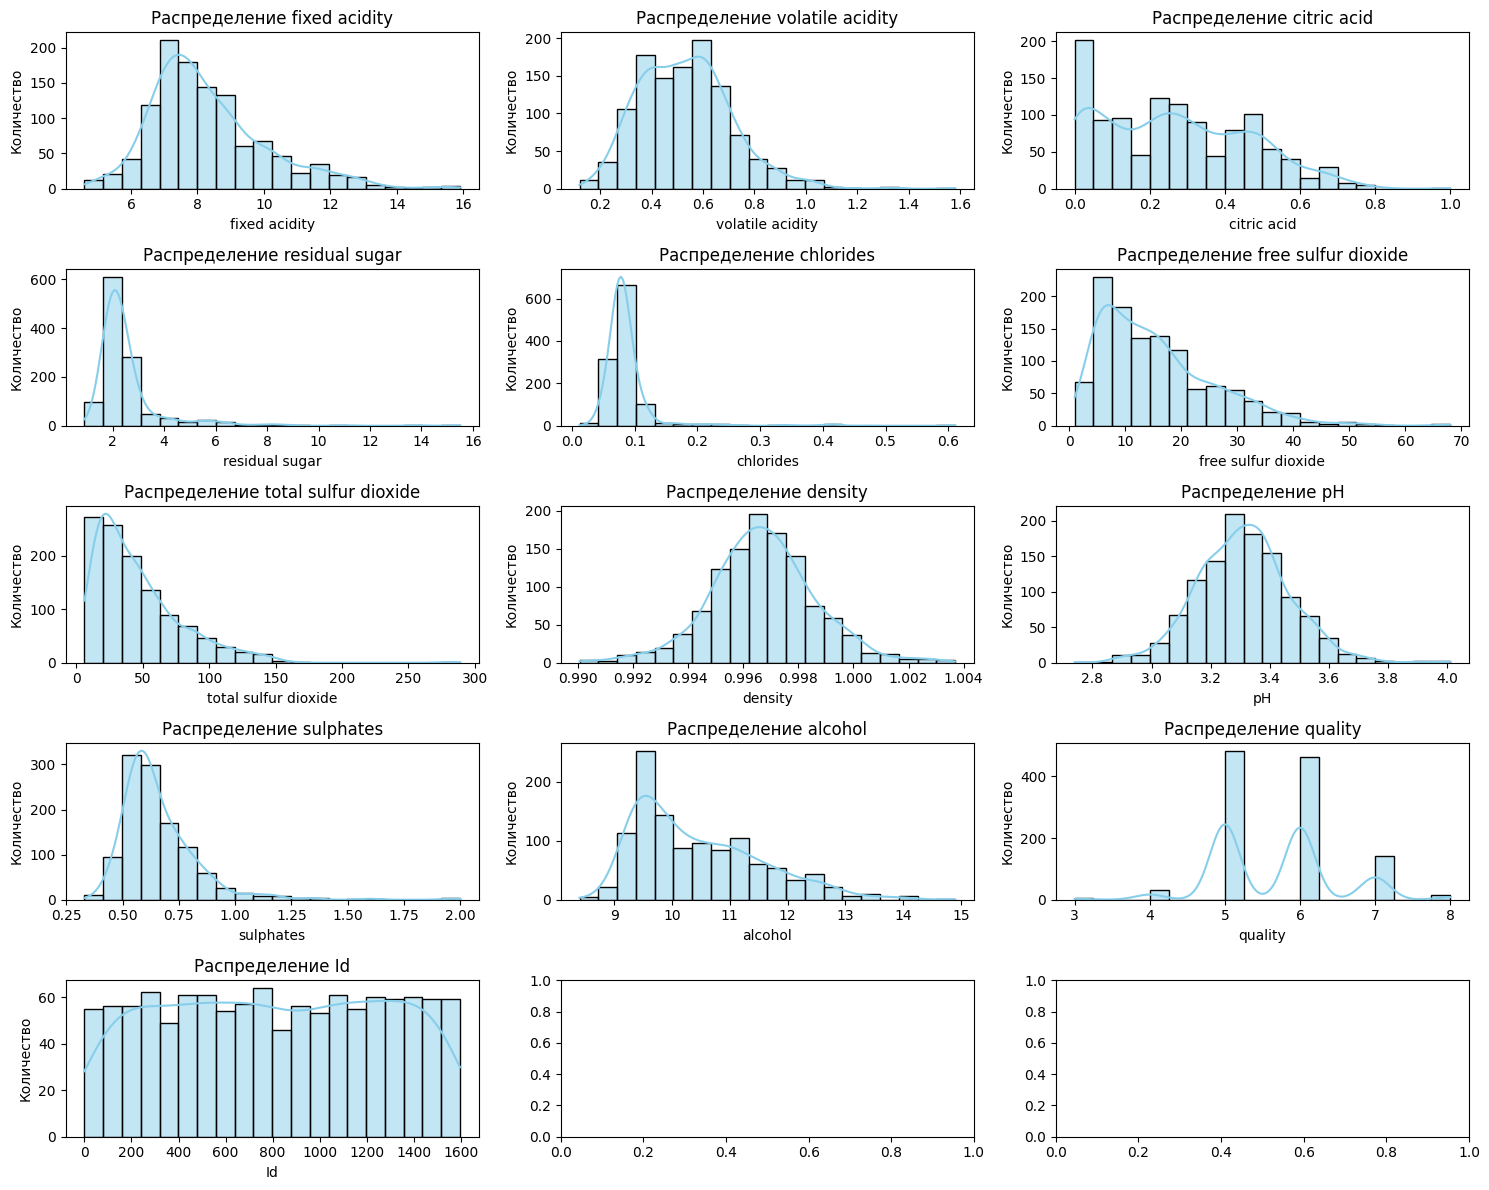

In [8]:
%matplotlib inline
# Распределение числовых признаков
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data[col], ax=ax, kde=True, bins=20, color='skyblue')
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [9]:
# Описательная статистика
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


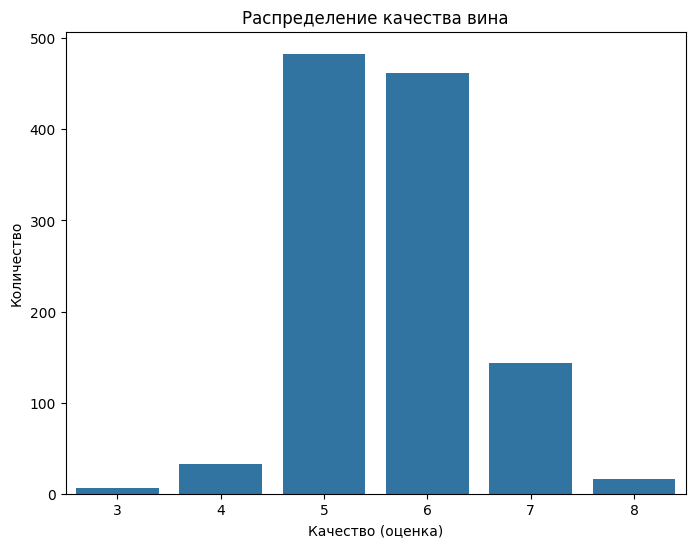

In [10]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=data)
plt.title('Распределение качества вина')
plt.xlabel('Качество (оценка)')
plt.ylabel('Количество')
plt.show()

In [11]:
# Удаление ненужного столбца 'Id'
data = data.drop(columns=['Id'], errors='ignore')

In [12]:
# Проверка на дубликаты
data.duplicated().sum()

np.int64(125)

In [13]:
# Удаление дубликатов
data = data.drop_duplicates()

In [14]:
# Преобразование качества в бинарную классификацию (хорошее/плохое вино)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)

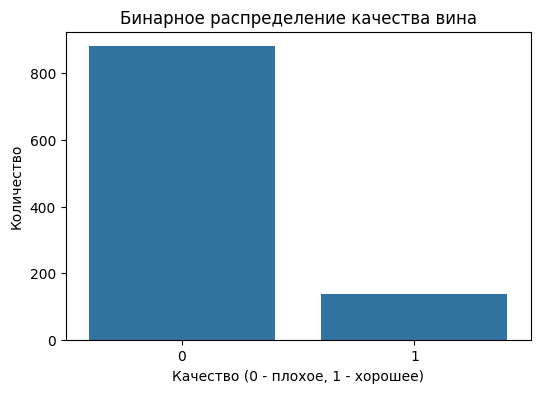

In [15]:
# Визуализация нового распределения классов
plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=data)
plt.title('Бинарное распределение качества вина')
plt.xlabel('Качество (0 - плохое, 1 - хорошее)')
plt.ylabel('Количество')
plt.show()

Данные очищены, сильных выбросов не наблюдается. Датасет можно брать в обработку.

### 3) Разделение выборки на обучающую и тестовую с использованием метода train_test_split

In [16]:
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,0
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,1
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,1
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,0
10,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,0


In [17]:
# Разделение на признаки и целевую переменную
X = data.drop('quality', axis=1)
y = data['quality']

In [18]:
# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
# Проверка размеров выборок
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Обучающая выборка: 814 samples
Тестовая выборка: 204 samples


### 4) Обучение следующих ансамблевых моделей.

#### 4.1) Одна из моделей группы стекинга (stacking)

In [21]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Определение базовых моделей
estimators = [
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('lr', LogisticRegression(random_state=42))
]

# Создание мета-модели
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

# Обучение модели
stacking_model.fit(X_train, y_train)
stacking_pred = stacking_model.predict(X_test)

# Оценка качества
print("Stacking Classifier:")
print(classification_report(y_test, stacking_pred))

Stacking Classifier:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       177
           1       0.57      0.30      0.39        27

    accuracy                           0.88       204
   macro avg       0.74      0.63      0.66       204
weighted avg       0.86      0.88      0.86       204



#### 4.2) Модель многослойного персептрона (MLP)

MLP Classifier:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       177
           1       0.54      0.52      0.53        27

    accuracy                           0.88       204
   macro avg       0.73      0.73      0.73       204
weighted avg       0.88      0.88      0.88       204



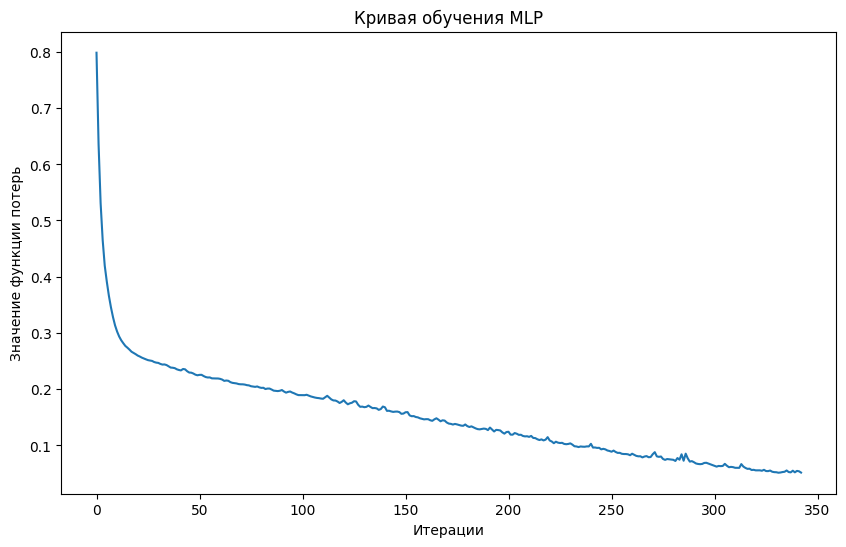

In [22]:
from sklearn.neural_network import MLPClassifier

# Создание и обучение модели
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

# Оценка качества
print("MLP Classifier:")
print(classification_report(y_test, mlp_pred))

# Визуализация кривой обучения
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_)
plt.title('Кривая обучения MLP')
plt.xlabel('Итерации')
plt.ylabel('Значение функции потерь')
plt.show()

#### 4.3) Методы МГУА (для регрессии)

Линейная регрессия MSE: 0.3856
Линейная регрессия R²: 0.3368
Дерево решений MSE: 0.7755
Дерево решений R²: -0.3338


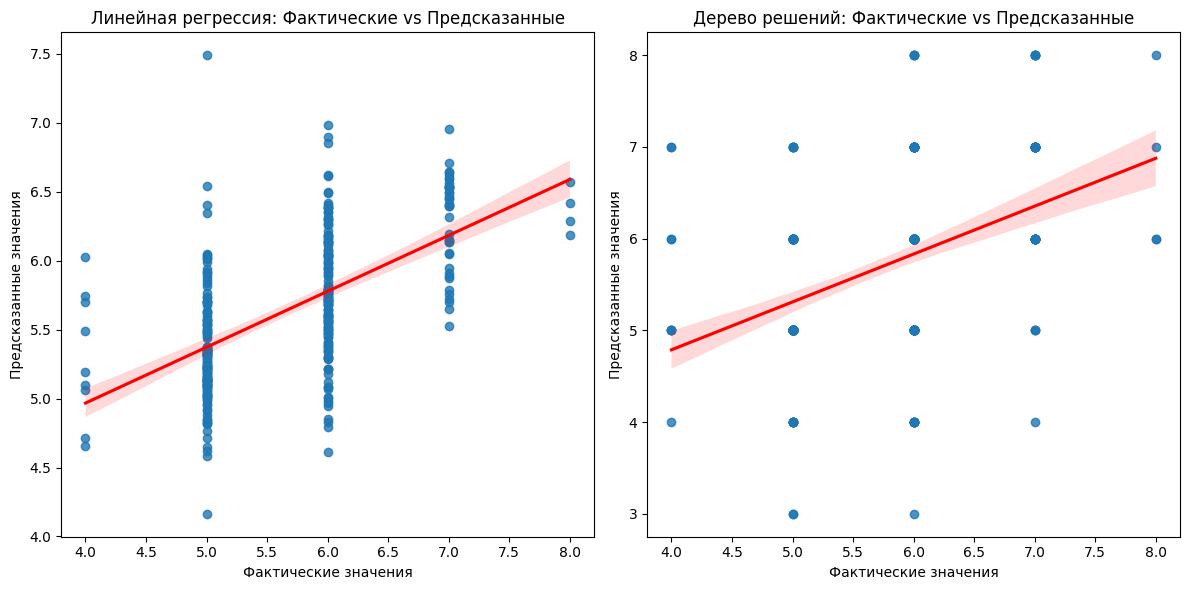

In [25]:
# 4.3 Методы МГУА (для регрессии) с обработкой всех ошибок

# Импорт всех необходимых библиотек
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('WineQT.csv')  
X_reg = data.drop(['quality', 'Id'], axis=1) 
y_reg = data['quality']  # Исходные значения качества (0-10)

# Масштабирование признаков
scaler = StandardScaler()
X_scaled_reg = scaler.fit_transform(X_reg)

# Разделение на обучающую и тестовую выборки
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_reg, y_reg, test_size=0.3, random_state=42
)

# Линейная альтернатива COMBI
linear = LinearRegression()
linear.fit(X_train_reg, y_train_reg)
linear_pred = linear.predict(X_test_reg)
linear_mse = mean_squared_error(y_test_reg, linear_pred)
print(f"Линейная регрессия MSE: {linear_mse:.4f}")
print(f"Линейная регрессия R²: {r2_score(y_test_reg, linear_pred):.4f}")

data = pd.read_csv('WineQT.csv')  
X_reg = data.drop(['quality', 'Id'], axis=1) 
y_reg = data['quality']  # Исходные значения качества (0-10)

# Масштабирование признаков
scaler = StandardScaler()
X_scaled_reg = scaler.fit_transform(X_reg)

# Разделение на обучающую и тестовую выборки
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_reg, y_reg, test_size=0.3, random_state=42
)

# Нелинейная альтернатива MIA
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_reg, y_train_reg)
tree_pred = tree.predict(X_test_reg)
tree_mse = mean_squared_error(y_test_reg, tree_pred)
print(f"Дерево решений MSE: {tree_mse:.4f}")
print(f"Дерево решений R²: {r2_score(y_test_reg, tree_pred):.4f}")

# Визуализация альтернатив
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.regplot(x=y_test_reg, y=linear_pred, line_kws={'color': 'red'})
plt.title('Линейная регрессия: Фактические vs Предсказанные')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')

plt.subplot(1, 2, 2)
sns.regplot(x=y_test_reg, y=tree_pred, line_kws={'color': 'red'})
plt.title('Дерево решений: Фактические vs Предсказанные')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')

plt.tight_layout()
plt.show()

#### 5) Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

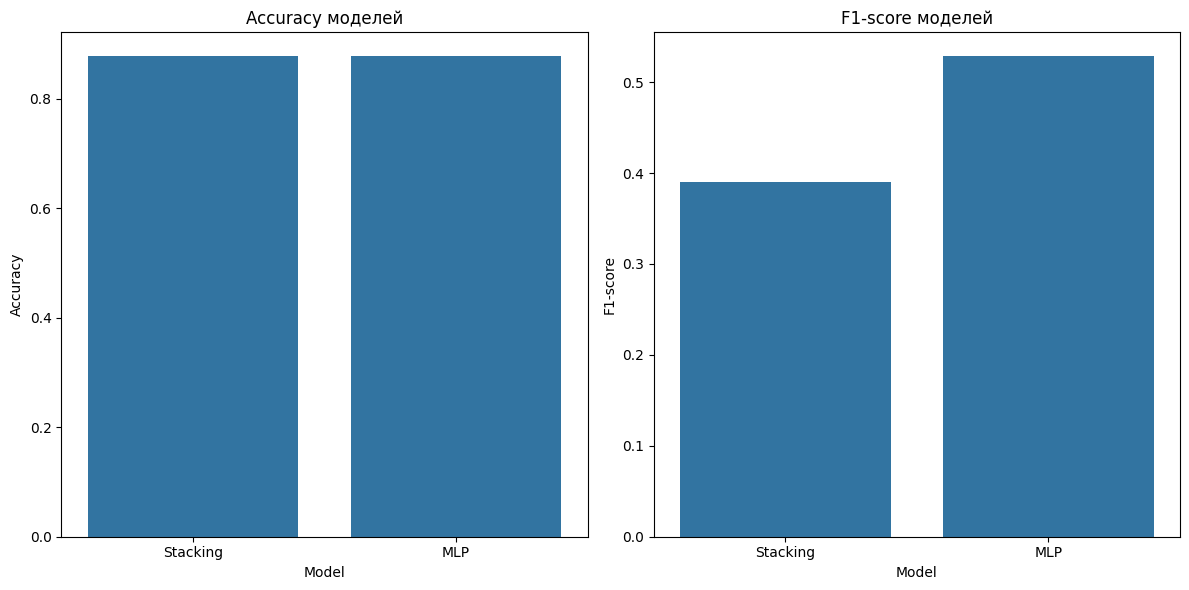

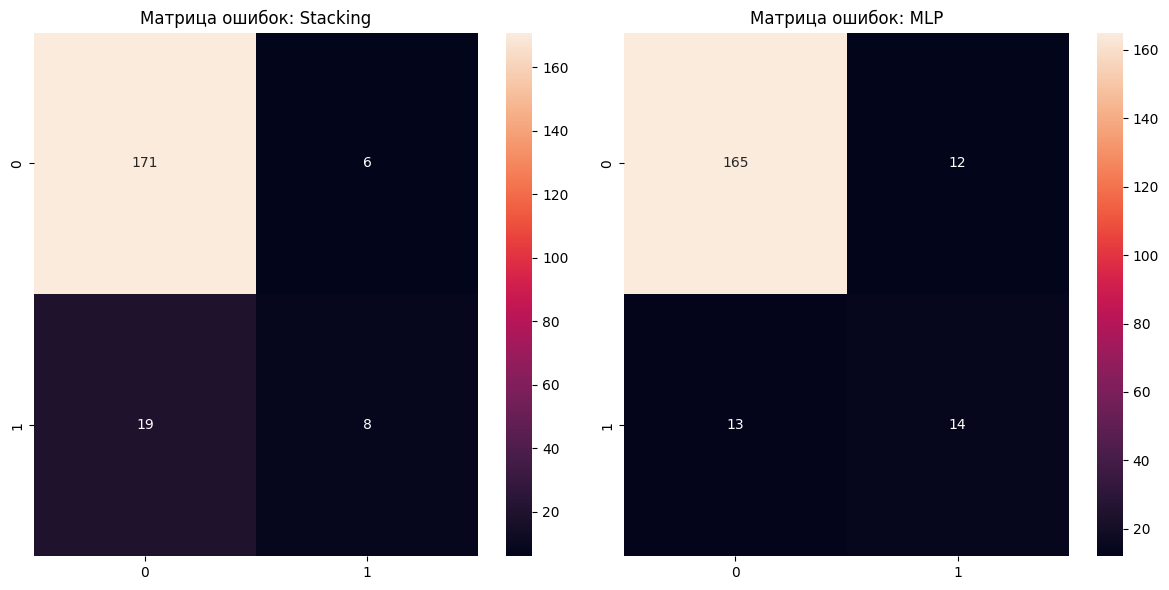

In [24]:
# Сбор метрик
models = {
    'Stacking': stacking_pred,
    'MLP': mlp_pred
}

metrics = []
for name, pred in models.items():
    accuracy = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    metrics.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-score': f1
    })

# Визуализация сравнения
metrics_df = pd.DataFrame(metrics)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=metrics_df)
plt.title('Accuracy моделей')
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1-score', data=metrics_df)
plt.title('F1-score моделей')
plt.tight_layout()
plt.show()

# Матрицы ошибок
plt.figure(figsize=(12, 6))
for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(1, 2, i)
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
    plt.title(f'Матрица ошибок: {name}')
plt.tight_layout()
plt.show()